# 05 · The three runs side by side

Reads what notebooks 02, 03 and 04 wrote to `results/runs/` and `results/max_batch.json`; trains nothing.
Writes `results/summary.json`, `results/summary.md` and the figures the README shows.

In [1]:
import sys, os, json, pathlib, subprocess
IN_COLAB = "google.colab" in sys.modules
if IN_COLAB and not pathlib.Path("ERA_V5").exists():
    subprocess.run(["git", "clone", "--depth", "1", "https://github.com/amukka/ERA_V5.git"], check=True)
    os.chdir("ERA_V5/session13_Distributed_Training")
ROOT = pathlib.Path.cwd()
while not (ROOT / "src").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
os.chdir(ROOT); sys.path.insert(0, str(ROOT))
if not (ROOT / "data" / "train.bin").exists():          # ~5 minutes: stream FineWeb-Edu, train the BPE
    subprocess.run([sys.executable, "tools/prepare_data.py"], check=True)

import torch, platform
from src import experiments as X
from src.train import pick_device
dev = pick_device()
print("device:", dev, "| torch", torch.__version__, "| python", platform.python_version(), "|", platform.platform())
if dev == "mps":
    print(f"MPS recommended working set: {torch.mps.recommended_max_memory()/2**30:.2f} GiB")
if dev == "cuda":
    print(torch.cuda.get_device_name(), f"{torch.cuda.get_device_properties(0).total_memory/2**30:.1f} GiB")
print(json.dumps(json.loads((ROOT / "data" / "meta.json").read_text()), indent=1))

device: mps | torch 2.13.0 | python 3.14.5 | macOS-26.6.2-arm64-arm-64bit-Mach-O
MPS recommended working set: 11.84 GiB
{
 "source": "HuggingFaceFW/fineweb-edu, config sample-10BT, streamed in order",
 "vocab_size": 8192,
 "eos_id": 0,
 "train_tokens": 56000000,
 "train_docs": 46080,
 "val_tokens": 1000000,
 "val_docs": 1024,
 "chars_per_token": 3.886,
 "note": "val.bin comes from the tokenizer's training documents; train.bin from the documents after them",
 "seconds": 314.3
}


In [2]:
import math
import matplotlib.pyplot as plt
chosen = json.loads((X.RESULTS / "chosen_variant.json").read_text())
V = chosen["variant"]
RUNS = {"baseline (standard, b32)": "baseline_standard_b32",
        f"reversible {V} (b32)": f"reversible_{V}_b32",
        f"reversible {V} (max batch)": f"reversible_{V}_maxbatch"}
S = {k: X.load(v) for k, v in RUNS.items()}
L = {k: X.load_log(v) for k, v in RUNS.items()}
mb = json.loads((X.RESULTS / "max_batch.json").read_text())

audit_path = X.RESULTS / "memory_audit.json"
AUD = {(a["variant"], a["batch"], a["loss_chunk"]): max(t["peak_mib"] for t in a["steps"])
       for a in json.loads(audit_path.read_text())} if audit_path.exists() else {}
rows = []
for k, s in S.items():
    rv = (s["reversibility"] or {}).get("final") or {}
    rows.append({"run": k, "batch": s["batch"], "steps": s["steps"], "peak_lr": s["peak_lr"],
                 "final_train_loss": s["final_train_loss_avg_last5pct"], "final_val_loss": s["final_val_loss"],
                 "tok_per_s": s["tok_per_s"], "train_minutes": s["train_seconds"] / 60,
                 "tok_per_s_median_interval": sorted(r["tok_per_s"] for r in L[k] if r["type"] == "step" and r["tok_per_s"])[
                     len([r for r in L[k] if r["type"] == "step" and r["tok_per_s"]]) // 2],
                 "peak_exact_mib": AUD.get((s["config"]["variant"], s["batch"], 0), s["peak_exact_mib"]),
                 "peak_unsynced_audit_mib": s["peak_exact_mib"], "peak_driver_mib": s["peak_driver_mib"],
                 "peak_op": s["peak_exact_op"], "grad_cosine_vs_autograd": rv.get("grad_cosine")})
b = rows[0]
hdr = "| run | batch | steps | final train loss | final val loss | tokens/s | minutes | peak memory (synced audit) | Metal driver peak | vs baseline: speed | vs baseline: memory |"
lines = [hdr, "|" + "---|" * 11]
for r in rows:
    lines.append(f"| {r['run']} | {r['batch']} | {r['steps']:,} | {r['final_train_loss']:.4f} | {r['final_val_loss']:.4f} | "
                 f"{r['tok_per_s']:,.0f} | {r['train_minutes']:.1f} | {r['peak_exact_mib']/1024:.2f} GiB | {r['peak_driver_mib']/1024:.2f} GiB | "
                 f"{r['tok_per_s']/b['tok_per_s']:.2f}x | {r['peak_exact_mib']/b['peak_exact_mib']:.2f}x |")
table = "\n".join(lines)
(X.RESULTS / "summary.json").write_text(json.dumps({"runs": rows, "max_batch": mb}, indent=2))
(X.RESULTS / "summary.md").write_text(table + "\n")
from IPython.display import Markdown, display
display(Markdown(table))

| run | batch | steps | final train loss | final val loss | tokens/s | minutes | peak memory (synced audit) | Metal driver peak | vs baseline: speed | vs baseline: memory |
|---|---|---|---|---|---|---|---|---|---|---|
| baseline (standard, b32) | 32 | 3,051 | 3.9759 | 3.9801 | 10,983 | 75.8 | 9.15 GiB | 11.56 GiB | 1.00x | 1.00x |
| reversible momentum (b32) | 32 | 3,051 | 4.0136 | 4.0206 | 8,925 | 93.3 | 2.65 GiB | 6.07 GiB | 0.81x | 0.29x |
| reversible momentum (max batch) | 88 | 1,109 | 4.1624 | 4.1808 | 7,776 | 107.0 | 5.93 GiB | 11.28 GiB | 0.71x | 0.65x |

## Loss against tokens, and against wall-clock time

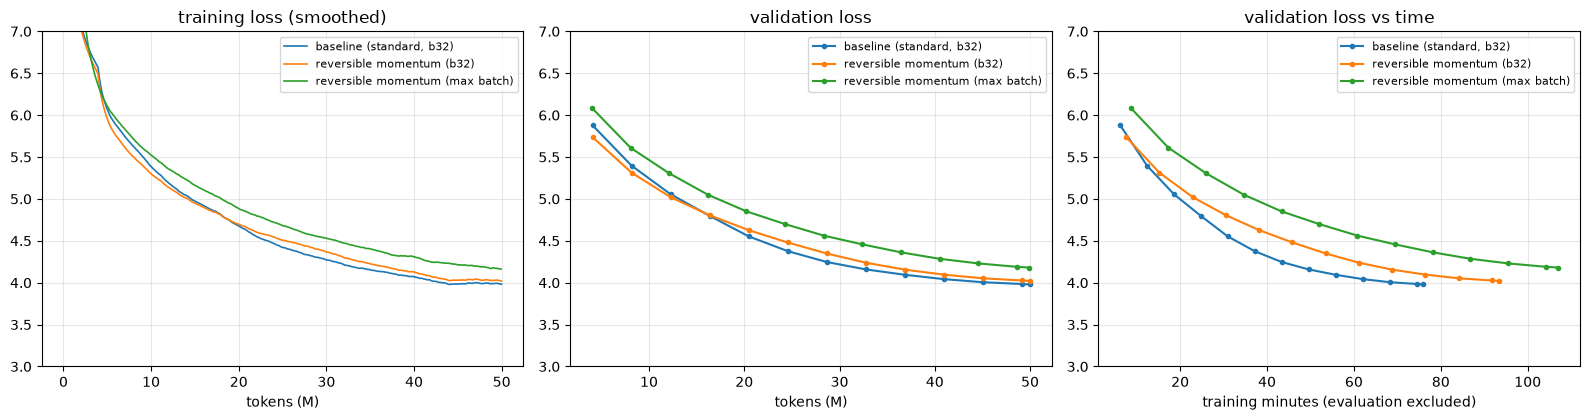

In [3]:
def smooth(y, k=25):
    out, acc = [], []
    for v in y:
        acc.append(v); acc = acc[-k:]; out.append(sum(acc) / len(acc))
    return out
fig, ax = plt.subplots(1, 3, figsize=(16, 4.3))
for k, log in L.items():
    st = [r for r in log if r["type"] == "step"]; ev = [r for r in log if r["type"] == "eval"]
    ax[0].plot([r["tokens"]/1e6 for r in st], smooth([r["loss"] for r in st]), label=k, lw=1.2)
    ax[1].plot([r["tokens"]/1e6 for r in ev], [r["val_loss"] for r in ev], "o-", ms=3, label=k)
    # wall clock of each eval: the train_time of the last step logged before it
    import numpy as np
    mins = np.interp([r["tokens"] for r in ev], [r["tokens"] for r in st], [r["train_time"] for r in st]) / 60
    ax[2].plot(mins, [r["val_loss"] for r in ev], "o-", ms=3, label=k)
ax[0].set(xlabel="tokens (M)", title="training loss (smoothed)", ylim=(3, 7))
ax[1].set(xlabel="tokens (M)", title="validation loss", ylim=(3, 7))
ax[2].set(xlabel="training minutes (evaluation excluded)", title="validation loss vs time", ylim=(3, 7))
for a in ax: a.grid(alpha=.3); a.legend(fontsize=8)
plt.tight_layout(); plt.savefig(X.RESULTS / "loss_curves.png", dpi=120); plt.show()

## Peak memory, measured so that it repeats

`python -m src.memory_audit` meters two training steps per configuration op by op, with the GPU
synchronised after every op (MPS keeps a freed buffer counted until the GPU has finished with it, so
unsynchronised readings drift by up to ~25% between identical runs). The two steps agree to within 0.3%.

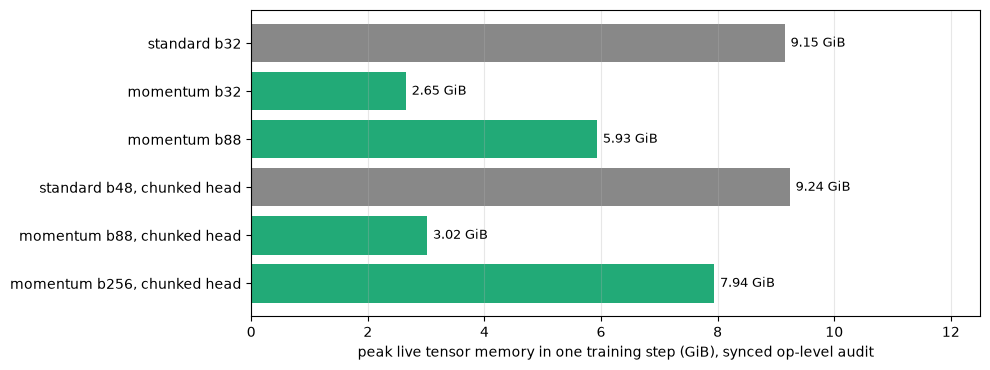

standard b32                   [9370.5, 9370.5] aten._log_softmax_backward_data.default
momentum b32                   [2715.7, 2715.7] aten._log_softmax_backward_data.default
momentum b88                   [6072.9, 6073.3] aten._log_softmax_backward_data.default
standard b48, chunked head     [9458.7, 9458.7] aten._log_softmax_backward_data.default
momentum b88, chunked head     [3089.6, 3079.8] aten._softmax_backward_data.default
momentum b256, chunked head    [8131.6, 8131.6] aten._softmax_backward_data.default


In [4]:
aud = json.loads((X.RESULTS / "memory_audit.json").read_text())
fig, ax = plt.subplots(figsize=(10, 3.8))
names = [a["config"] for a in aud]; vals = [max(t["peak_mib"] for t in a["steps"]) / 1024 for a in aud]
bars = ax.barh(names[::-1], vals[::-1], color=["#888" if "standard" in n else "#2a7" for n in names[::-1]])
for b_, v in zip(bars, vals[::-1]):
    ax.text(v + 0.1, b_.get_y() + b_.get_height() / 2, f"{v:.2f} GiB", va="center", fontsize=9)
ax.set_xlabel("peak live tensor memory in one training step (GiB), synced op-level audit")
ax.set_xlim(0, 12.5); ax.grid(alpha=.3, axis="x")
plt.tight_layout(); plt.savefig(X.RESULTS / "memory_audit.png", dpi=120); plt.show()
for a in aud:
    print(f"{a['config']:30s}", [t["peak_mib"] for t in a["steps"]], a["steps"][0]["op"])

## Memory against batch size

Every probe from the max-batch search, for both stacks. Peak memory is close to a straight line in the
batch: an intercept (weights, gradients, AdamW state, allocator overhead) plus a slope, the memory one more
sequence of 512 tokens costs. The slope is where reversibility acts.

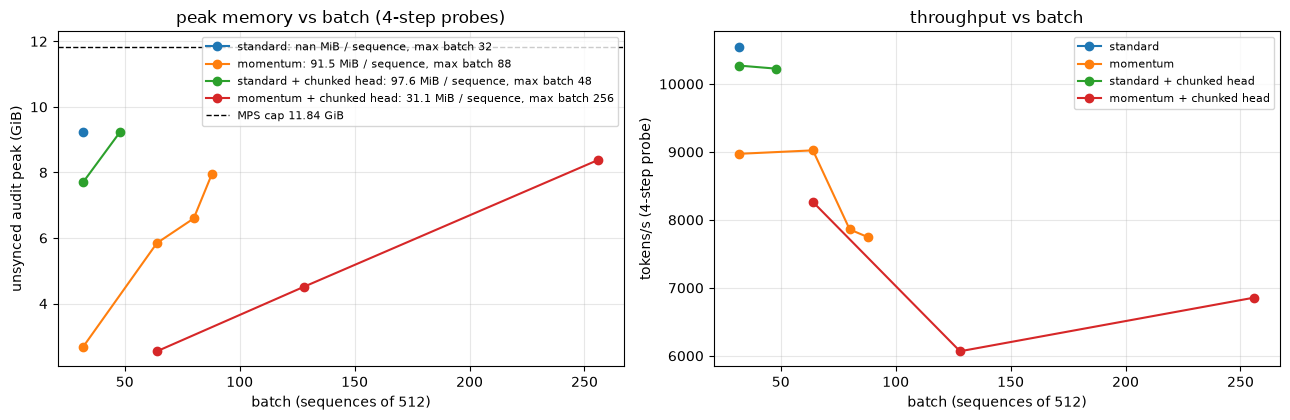

{
 "standard": {
  "slope_mib_per_seq": NaN,
  "intercept_mib": NaN,
  "max_batch": 32
 },
 "momentum": {
  "slope_mib_per_seq": 91.5267391304348,
  "intercept_mib": -127.71478260869708,
  "max_batch": 88
 },
 "standard + chunked head": {
  "slope_mib_per_seq": 97.59374999999994,
  "intercept_mib": 4775.100000000002,
  "max_batch": 48
 },
 "momentum + chunked head": {
  "slope_mib_per_seq": 31.109374999999996,
  "intercept_mib": 625.1999999999971,
  "max_batch": 256
 }
}
one fp32 logits tensor for one sequence: 16 MiB (512 x 8192 x 4 bytes)


In [5]:
import numpy as np
fig, ax = plt.subplots(1, 2, figsize=(13, 4.3))
fits = {}
series = dict(mb)
chunk_path = X.RESULTS / "max_batch_chunked_head.json"
if chunk_path.exists():
    series.update({f"{k} + chunked head": v for k, v in json.loads(chunk_path.read_text()).items()})
for name, d in series.items():
    ok = [t for t in d["trail"] if t["fits"]]
    bs = np.array([t["batch"] for t in ok]); pk = np.array([t["peak_exact_mib"] for t in ok])
    slope, icpt = np.polyfit(bs, pk, 1) if len(bs) > 1 else (float("nan"), float("nan"))
    fits[name] = {"slope_mib_per_seq": slope, "intercept_mib": icpt, "max_batch": d["max_batch"]}
    ax[0].plot(bs, pk / 1024, "o-", label=f"{name}: {slope:.1f} MiB / sequence, max batch {d['max_batch']}")
    ax[1].plot(bs, [t["tok_per_s"] for t in ok], "o-", label=name)
cap = torch.mps.recommended_max_memory() / 2**30 if dev == "mps" else None
if cap: ax[0].axhline(cap, color="k", ls="--", lw=1, label=f"MPS cap {cap:.2f} GiB")
ax[0].set(xlabel="batch (sequences of 512)", ylabel="unsynced audit peak (GiB)", title="peak memory vs batch (4-step probes)")
ax[1].set(xlabel="batch (sequences of 512)", ylabel="tokens/s (4-step probe)", title="throughput vs batch")
for a in ax: a.grid(alpha=.3); a.legend(fontsize=8)
plt.tight_layout(); plt.savefig(X.RESULTS / "memory_vs_batch.png", dpi=120); plt.show()
logits_mib = 512 * 8192 * 4 / 2**20
print(json.dumps(fits, indent=1))
print(f"one fp32 logits tensor for one sequence: {logits_mib:.0f} MiB (512 x 8192 x 4 bytes)")
json.dump(fits, open(X.RESULTS / "memory_fits.json", "w"), indent=2)